In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


 ## Load Dataset

In [2]:
df = pd.read_csv('/Users/charitha/Downloads/online_retail.csv', encoding='utf-8-sig')

## Preview Data

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Dataset Info


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## Summary Statistics

In [5]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2011-10-31 14:41:00,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


## Check Missing Values

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Remove Cancelled Orders

In [7]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Shape after removing cancellations: {df.shape}")

Shape after removing cancellations: (532621, 8)


## Drop Missing Descriptions

In [8]:
df.dropna(subset=['Description'], inplace=True)
print(f"Shape after dropping missing descriptions: {df.shape}")

Shape after dropping missing descriptions: (531167, 8)


## Handle Missing CustomerID

In [9]:
df['CustomerID'] = df['CustomerID'].fillna(0).astype(int)

## Remove Invalid Quantities & Prices

In [10]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print(f"Shape after removing invalid rows: {df.shape}")

Shape after removing invalid rows: (530104, 8)


## Verify No Missing Values Remain

In [11]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## Rename Columns to Snake Case

In [12]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

## Convert Date Column

In [13]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'])
df[['invoicedate']].head()

,invoicedate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


## Feature Engineering: TotalPrice

In [14]:
df['total_price'] = df['quantity'] * df['unitprice']
df[['quantity', 'unitprice', 'total_price']].head(10)

,quantity,unitprice,total_price
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


## Feature Engineering: Date Parts

In [15]:
df['month']       = df['invoicedate'].dt.month
df['year']        = df['invoicedate'].dt.year
df['day_of_week'] = df['invoicedate'].dt.day_name()
df['hour']        = df['invoicedate'].dt.hour

df[['invoicedate', 'month', 'year', 'day_of_week', 'hour']].head(10)

,invoicedate,month,year,day_of_week,hour
0,2010-12-01 08:26:00,12,2010,Wednesday,8
1,2010-12-01 08:26:00,12,2010,Wednesday,8
2,2010-12-01 08:26:00,12,2010,Wednesday,8
3,2010-12-01 08:26:00,12,2010,Wednesday,8
4,2010-12-01 08:26:00,12,2010,Wednesday,8
5,2010-12-01 08:26:00,12,2010,Wednesday,8
6,2010-12-01 08:26:00,12,2010,Wednesday,8
7,2010-12-01 08:28:00,12,2010,Wednesday,8
8,2010-12-01 08:28:00,12,2010,Wednesday,8
9,2010-12-01 08:34:00,12,2010,Wednesday,8


## Final Columns

In [16]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'total_price', 'month', 'year',
       'day_of_week', 'hour'],
      dtype='object')

##  Revenue Summary


In [44]:
print(f"Total Revenue:    ${df['total_price'].sum():,.2f}")
print(f"Total Orders:     {df['invoiceno'].nunique():,}")
print(f"Total Customers:  {df['customerid'].nunique():,}")
print(f"Total Products:   {df['description'].nunique():,}")
print(f"Total Countries:  {df['country'].nunique():,}")

Total Revenue:    $10,666,684.54
Total Orders:     19,962
Total Customers:  4,339
Total Products:   4,026
Total Countries:  38


## Top 10 Products by Quantity

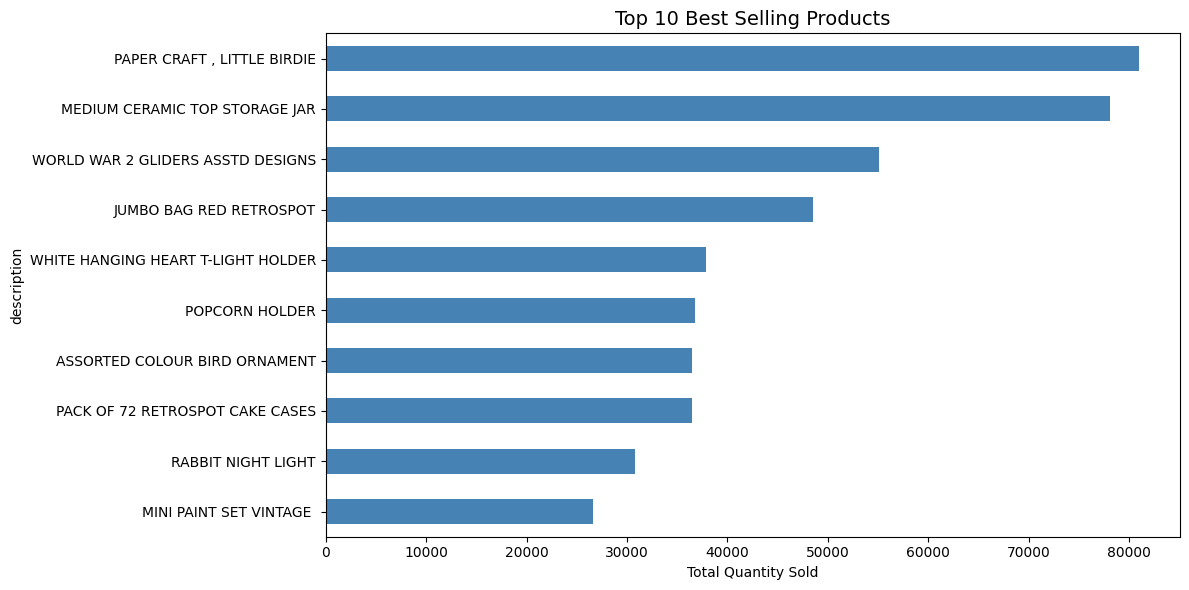

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_products.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Best Selling Products', fontsize=14)
plt.xlabel('Total Quantity Sold')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

## Top 10 Countries by Revenue

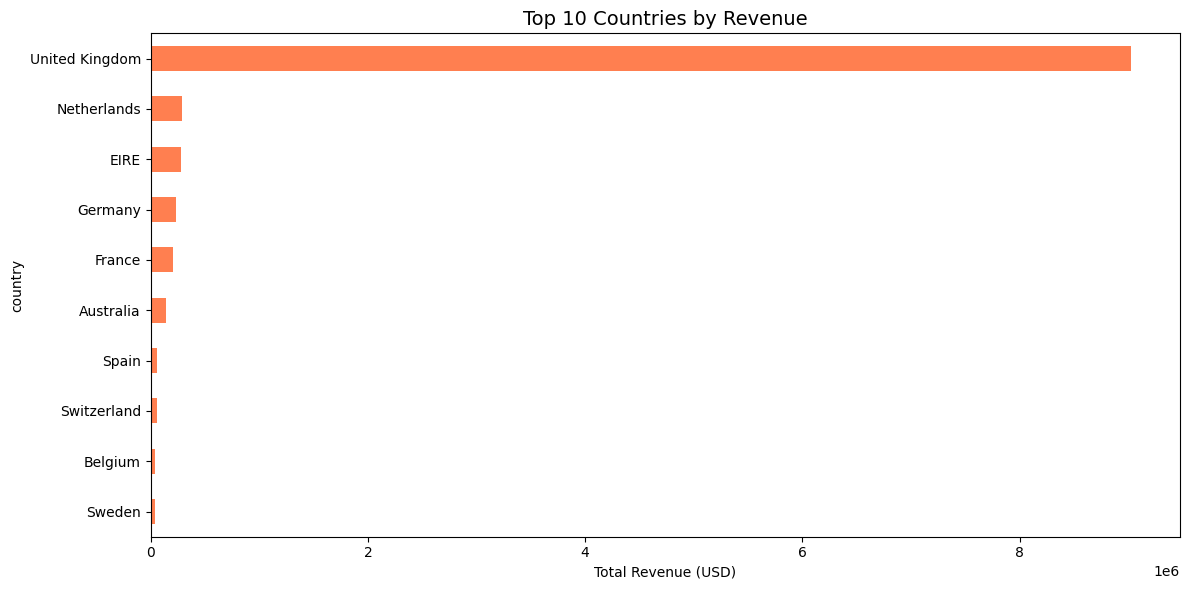

In [19]:
top_countries = df.groupby('country')['total_price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_countries.sort_values().plot(kind='barh', color='coral')
plt.title('Top 10 Countries by Revenue', fontsize=14)
plt.xlabel('Total Revenue (USD)')
plt.tight_layout()
plt.savefig('top_countries.png')
plt.show()

## Monthly Revenue Trend

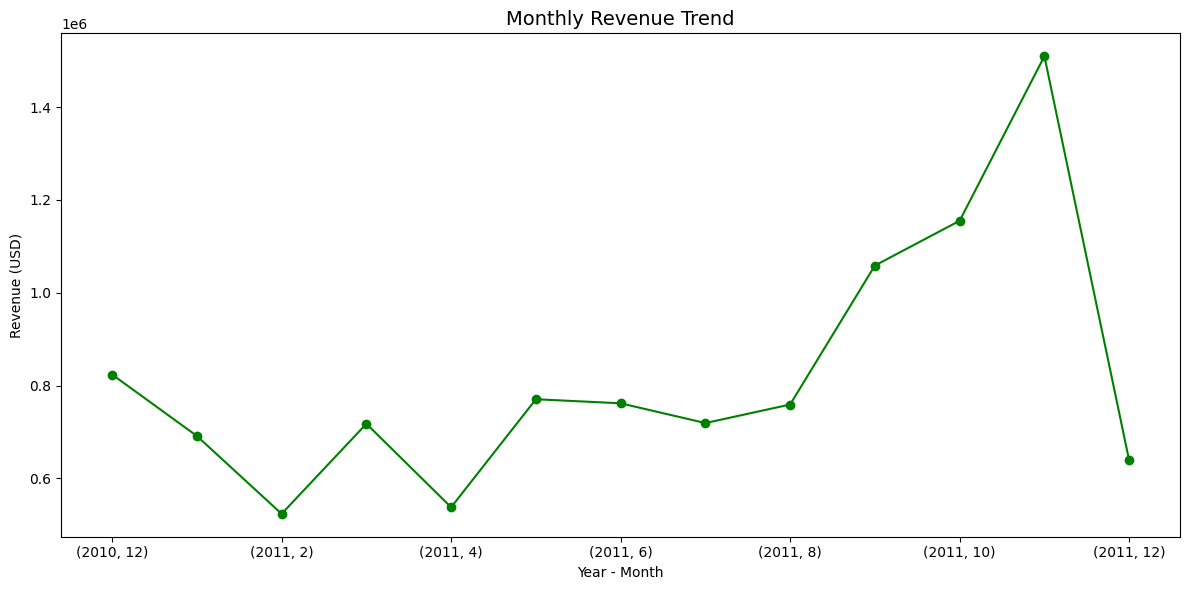

In [20]:
monthly = df.groupby(['year', 'month'])['total_price'].sum()

plt.figure(figsize=(12, 6))
monthly.plot(kind='line', marker='o', color='green')
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Year - Month')
plt.ylabel('Revenue (USD)')
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

## Revenue by Day of Week

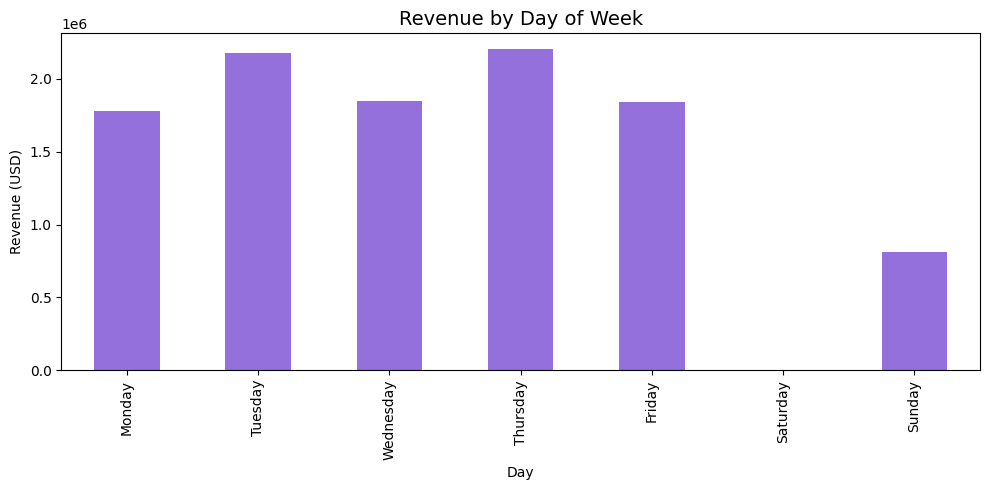

In [21]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = df.groupby('day_of_week')['total_price'].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
day_sales.plot(kind='bar', color='mediumpurple')
plt.title('Revenue by Day of Week', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Revenue (USD)')
plt.tight_layout()
plt.savefig('day_of_week.png')
plt.show()

## Save Cleaned Data

In [45]:
df.to_csv('online_retail_cleaned.csv', index=False)
print("Cleaned data saved as online_retail_cleaned.csv")

Cleaned data saved as online_retail_cleaned.csv


## Setup SQL Connection

In [46]:
import sqlite3
from sqlalchemy import create_engine

engine = create_engine('sqlite:///online_retail.db')
df.to_sql('retail', engine, if_exists='replace', index=False)

print("Data successfully loaded into SQLite database 'online_retail.db'")

Data successfully loaded into SQLite database 'online_retail.db'


In [47]:
# Reconnect to SQLite and reload data

import sqlite3
import pandas as pd

# Load cleaned dataframe
df = pd.read_csv('/Users/charitha/online_retail_cleaned.csv')

# Reconnect to SQLite
conn = sqlite3.connect('/Users/charitha/online_retail.db')

# Reload data into table
df.to_sql('retail', conn, if_exists='replace', index=False)

print("Table 'retail' reloaded successfully!")
print("Total rows:", pd.read_sql("SELECT COUNT(*) FROM retail", conn).iloc[0,0])

/var/folders/q8/qgr7gcxd5ql2mf1_j6yt_lc40000gn/T/ipykernel_2100/913385038.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/charitha/online_retail_cleaned.csv')


Table 'retail' reloaded successfully!
Total rows: 530104


## Q1: Total Revenue by Country

In [25]:
# Q1. What is the total revenue generated by each country?

q1 = pd.read_sql("""
    SELECT country, 
           ROUND(SUM(total_price), 2) AS revenue
    FROM retail
    GROUP BY country
    ORDER BY revenue DESC
    LIMIT 10
""", conn)
q1

,country,revenue
0,United Kingdom,9025222.08
1,Netherlands,285446.34
2,EIRE,283453.96
3,Germany,228867.14
4,France,209715.11
5,Australia,138521.31
6,Spain,61577.11
7,Switzerland,57089.90
8,Belgium,41196.34
9,Sweden,38378.33


## Q2: High Value Orders Above Average

In [26]:
# Q2. Which invoices had a total price higher than the average order value?

q2 = pd.read_sql("""
    SELECT invoiceno, customerid, country,
           ROUND(SUM(total_price), 2) AS order_value
    FROM retail
    GROUP BY invoiceno, customerid, country
    HAVING SUM(total_price) >= (SELECT AVG(total_price) FROM retail)
    ORDER BY order_value DESC
    LIMIT 10
""", conn)
q2

,invoiceno,customerid,country,order_value
0,581483,16446,United Kingdom,168469.60
1,541431,12346,United Kingdom,77183.60
2,574941,0,United Kingdom,52940.94
3,576365,0,United Kingdom,50653.91
4,556444,15098,United Kingdom,38970.00
5,567423,17450,United Kingdom,31698.16
6,556917,12415,Australia,22775.93
7,572209,18102,United Kingdom,22206.00
8,567381,17450,United Kingdom,22104.80
9,563614,12415,Australia,21880.44


## Q3: Top 5 Products by Average Unit Price

In [27]:
# Q3. Which are the top 5 products with the highest average unit price?

q3 = pd.read_sql("""
    SELECT description, 
           ROUND(AVG(unitprice), 2) AS avg_unit_price
    FROM retail
    GROUP BY description
    ORDER BY avg_unit_price DESC
    LIMIT 5
""", conn)
q3

,description,avg_unit_price
0,Adjust bad debt,11062.06
1,AMAZON FEE,6880.55
2,PICNIC BASKET WICKER 60 PIECES,649.50
3,DOTCOM POSTAGE,292.14
4,Manual,230.15


## Q4: Revenue by Year

In [28]:
# Q4. Compare the total revenue between 2010 and 2011.

q4 = pd.read_sql("""
    SELECT year,
           ROUND(SUM(total_price), 2) AS total_revenue,
           COUNT(DISTINCT invoiceno) AS total_orders
    FROM retail
    GROUP BY year
    ORDER BY year
""", conn)
q4

,year,total_revenue,total_orders
0,2010,823746.14,1559
1,2011,9842938.40,18401


## Q5: Repeat vs One-Time Customers

In [29]:
# Q5. Do customers with more than 1 order spend more on average?

q5 = pd.read_sql("""
    SELECT 
        CASE 
            WHEN order_count = 1 THEN 'One-Time Buyer'
            ELSE 'Repeat Buyer'
        END AS customer_type,
        COUNT(*) AS total_customers,
        ROUND(AVG(total_spent), 2) AS avg_spend,
        ROUND(SUM(total_spent), 2) AS total_revenue
    FROM (
        SELECT customerid,
               COUNT(DISTINCT invoiceno) AS order_count,
               SUM(total_price) AS total_spent
        FROM retail
        WHERE customerid != 0
        GROUP BY customerid
    )
    GROUP BY customer_type
    ORDER BY total_revenue DESC
""", conn)
q5

,customer_type,total_customers,avg_spend,total_revenue
0,Repeat Buyer,2845,2915.68,8295096.17
1,One-Time Buyer,1493,412.80,616311.73


## Q6: Top 5 Best Selling Products


In [30]:
# Q6. Which 5 products have the highest total quantity sold?

q6 = pd.read_sql("""
    SELECT description,
           SUM(quantity) AS total_quantity_sold,
           ROUND(SUM(total_price), 2) AS total_revenue
    FROM retail
    GROUP BY description
    ORDER BY total_quantity_sold DESC
    LIMIT 5
""", conn)
q6

,description,total_quantity_sold,total_revenue
0,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
1,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,55047,13841.85
3,JUMBO BAG RED RETROSPOT,48474,94340.05
4,WHITE HANGING HEART T-LIGHT HOLDER,37891,106292.77


## Q7: Customer Segmentation

In [31]:
# Q7. Segment customers into One-Time, Returning, and Loyal based on
# number of orders, and show the count of each segment.

q7 = pd.read_sql("""
    WITH customer_type AS (
        SELECT customerid,
               COUNT(DISTINCT invoiceno) AS order_count,
               CASE 
                   WHEN COUNT(DISTINCT invoiceno) = 1 THEN 'One-Time'
                   WHEN COUNT(DISTINCT invoiceno) BETWEEN 2 AND 5 THEN 'Returning'
                   ELSE 'Loyal'
               END AS customer_segment
        FROM retail
        WHERE customerid != 0
        GROUP BY customerid
    )
    SELECT customer_segment,
           COUNT(*) AS number_of_customers
    FROM customer_type
    GROUP BY customer_segment
    ORDER BY number_of_customers DESC
""", conn)
q7

,customer_segment,number_of_customers
0,Returning,1973
1,One-Time,1493
2,Loyal,872


## Q8: Top 3 Products per Month

In [32]:
# Q8. What are the top 3 most purchased products each month?

q8 = pd.read_sql("""
    WITH product_counts AS (
        SELECT month,
               description,
               SUM(quantity) AS total_qty,
               ROW_NUMBER() OVER (PARTITION BY month ORDER BY SUM(quantity) DESC) AS item_rank
        FROM retail
        GROUP BY month, description
    )
    SELECT item_rank, month, description, total_qty
    FROM product_counts
    WHERE item_rank <= 3
    ORDER BY month, item_rank
""", conn)
q8

,item_rank,month,description,total_qty
0,1,1,MEDIUM CERAMIC TOP STORAGE JAR,74215
1,2,1,WHITE HANGING HEART T-LIGHT HOLDER,5541
2,3,1,PACK OF 72 RETROSPOT CAKE CASES,3411
3,1,2,EMPIRE DESIGN ROSETTE,3986
4,2,2,GROW A FLYTRAP OR SUNFLOWER IN TIN,3795
5,3,2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,3518
6,1,3,JUMBO BAG RED RETROSPOT,5280
7,2,3,PACK OF 72 RETROSPOT CAKE CASES,3975
8,3,3,WORLD WAR 2 GLIDERS ASSTD DESIGNS,3888
9,1,4,WORLD WAR 2 GLIDERS ASSTD DESIGNS,10239


## Q9: UK vs Rest of World

In [33]:
# Q9. Are UK customers the biggest spenders compared to all other countries combined?

q9 = pd.read_sql("""
    SELECT 
        CASE WHEN country = 'United Kingdom' THEN 'United Kingdom'
             ELSE 'Rest of World'
        END AS region,
        COUNT(DISTINCT customerid) AS total_customers,
        ROUND(SUM(total_price), 2) AS total_revenue
    FROM retail
    GROUP BY region
    ORDER BY total_revenue DESC
""", conn)
q9

,region,total_customers,total_revenue
0,United Kingdom,3921,9025222.08
1,Rest of World,419,1641462.46


## Q10: Revenue by Hour of Day

In [34]:
# Q10. What is the revenue contribution of each hour of the day?

q10 = pd.read_sql("""
    SELECT hour,
           ROUND(SUM(total_price), 2) AS total_revenue
    FROM retail
    GROUP BY hour
    ORDER BY total_revenue DESC
""", conn)
q10

,hour,total_revenue
0,10,1446742.70
1,12,1444245.88
2,15,1352972.18
3,13,1265736.30
4,11,1239954.44
5,14,1181812.37
6,9,990267.82
7,16,754006.56
8,17,461603.49
9,8,283868.52


## K-Means RFM Customer Segmentation

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ensure invoicedate is datetime (may still be string if cell 25 wasn't re-run)
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

# Build RFM — exclude guest customers (CustomerID = 0)
snapshot_date = df['invoicedate'].max() + pd.Timedelta(days=1)

rfm = df[df['customerid'] != 0].groupby('customerid').agg(
    Recency   = ('invoicedate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('invoiceno',   'nunique'),
    Monetary  = ('total_price', 'sum')
).reset_index()

print(f"RFM table shape: {rfm.shape}")
rfm.head()

RFM table shape: (4338, 4)


,customerid,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


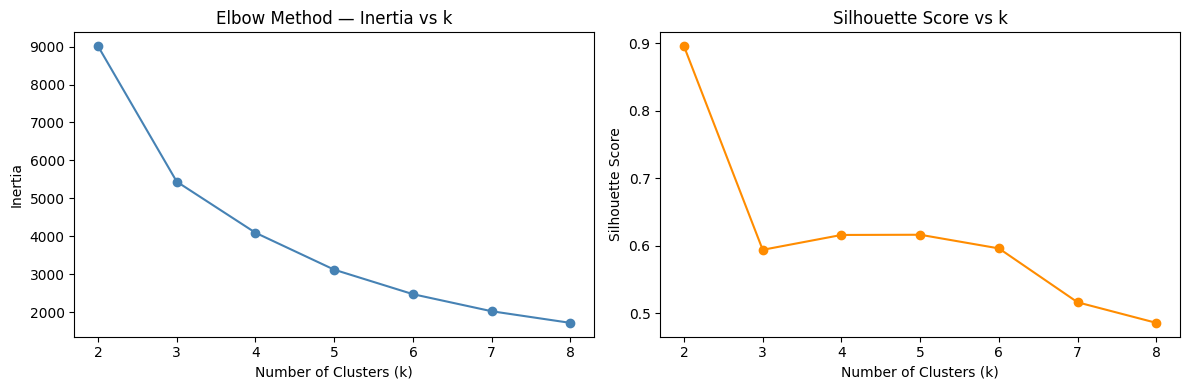

Best k by Silhouette: 2


In [37]:
# Scale features (critical — K-means is distance-based)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Find optimal k
inertia, sil_scores = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertia, marker='o', color='steelblue')
axes[0].set_title('Elbow Method — Inertia vs k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()
print("Best k by Silhouette:", K_range[sil_scores.index(max(sil_scores))])

In [38]:
# Fit with optimal k (adjust based on plots above — likely 3)
OPTIMAL_K = 3

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

final_sil = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f"Final Silhouette Score (k={OPTIMAL_K}): {final_sil:.3f}")

# Summarise clusters
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_summary['Count'] = rfm.groupby('Cluster')['customerid'].count().values
print(cluster_summary)

Final Silhouette Score (k=3): 0.594
         Recency  Frequency  Monetary  Count
Cluster                                     
0          247.1        1.6     631.4   1082
1           41.5        4.7    1855.9   3230
2            6.0       66.4   85904.4     26


In [39]:
# Label clusters based on mean values
# The cluster with lowest Recency + highest Frequency/Monetary = Loyal
# You may need to adjust the mapping after seeing your actual output

label_map = {
    cluster_summary['Monetary'].idxmax(): 'Loyal (High-Value)',
    cluster_summary['Recency'].idxmax():  'At-Risk / One-Time',
}
# Remaining cluster = Returning
remaining = [c for c in range(OPTIMAL_K) if c not in label_map][0]
label_map[remaining] = 'Returning'

rfm['Segment'] = rfm['Cluster'].map(label_map)

# Final distribution — this is the table that goes in your paper
seg_dist = rfm['Segment'].value_counts().reset_index()
seg_dist.columns = ['Segment', 'Count']
seg_dist['%'] = (seg_dist['Count'] / seg_dist['Count'].sum() * 100).round(1)
print(seg_dist)

              Segment  Count     %
0           Returning   3230  74.5
1  At-Risk / One-Time   1082  24.9
2  Loyal (High-Value)     26   0.6


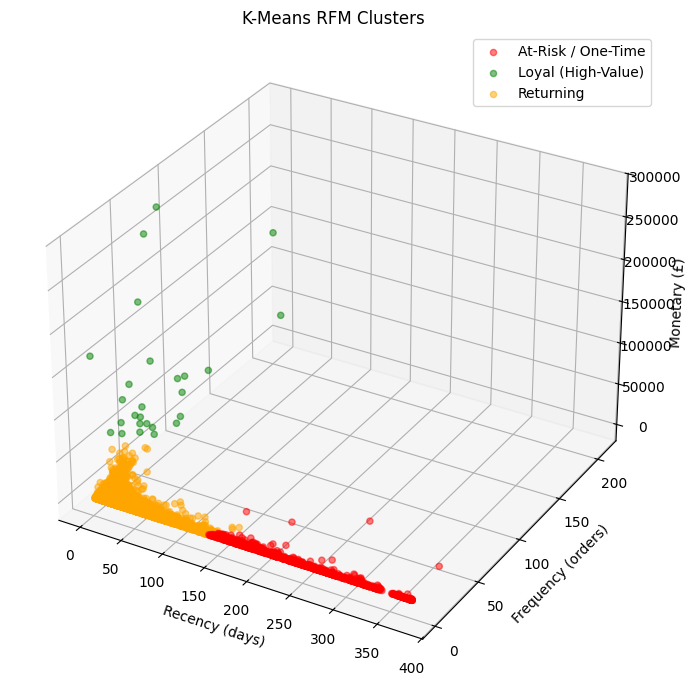

In [40]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = {'Loyal (High-Value)': 'green', 'Returning': 'orange', 'At-Risk / One-Time': 'red'}
for seg, grp in rfm.groupby('Segment'):
    ax.scatter(grp['Recency'], grp['Frequency'], grp['Monetary'],
               label=seg, alpha=0.5, s=20, c=colors[seg])

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (orders)')
ax.set_zlabel('Monetary (£)')
ax.set_title('K-Means RFM Clusters')
ax.legend()
plt.tight_layout()
plt.savefig('rfm_clusters_3d.png', dpi=150)
plt.show()

## Export All Results to Excel for Power BI

In [41]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])

import openpyxl
import pandas as pd

with pd.ExcelWriter('online_retail_analysis.xlsx', engine='openpyxl') as writer:
    q1.to_excel(writer,  sheet_name='Revenue_by_Country',   index=False)
    q2.to_excel(writer,  sheet_name='High_Value_Orders',    index=False)
    q3.to_excel(writer,  sheet_name='Top_Products_Price',   index=False)
    q4.to_excel(writer,  sheet_name='Revenue_by_Year',      index=False)
    q5.to_excel(writer,  sheet_name='Repeat_vs_OneTime',    index=False)
    q6.to_excel(writer,  sheet_name='Top_Products_Qty',     index=False)
    q7.to_excel(writer,  sheet_name='Customer_Segments',    index=False)
    q8.to_excel(writer,  sheet_name='Top_Products_Monthly', index=False)
    q9.to_excel(writer,  sheet_name='UK_vs_World',          index=False)
    q10.to_excel(writer, sheet_name='Revenue_by_Hour',      index=False)
    df.to_excel(writer,  sheet_name='Raw_Data',             index=False)

print("Excel file saved as online_retail_analysis.xlsx")
print("STEP 2 COMPLETE! Ready for Power BI!")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip


✅ Excel file saved as online_retail_analysis.xlsx
🎉 STEP 2 COMPLETE! Ready for Power BI!


In [42]:
import os
print("Current folder:", os.getcwd())

# List all files in current folder
files = os.listdir()
for f in files:
    if 'xlsx' in f or 'retail' in f:
        print("Found:", f)

Current folder: /Users/charitha
Found: online_retail_cleaned.csv
Found: online_retail.db
Found: online_retail_analysis.xlsx


import shutil
shutil.copy('/Users/charitha/online_retail_analysis.xlsx', '/Users/charitha/Desktop/online_retail_analysis.xlsx')
print("✅ File copied to Desktop!")